In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
import pyarrow.parquet as pq
trips = pq.read_table('Trips_phase1.parquet')
trips = trips.to_pandas()

<h3>Data Cleaning and PreProcessing</h3>

<h5>Statistical Data Analysis</h5>

In [46]:
negativeAndZeroValues=(trips['fare_amount'] <= 0.00).sum()
print(negativeAndZeroValues)


41545


In [47]:
stratified_sample = trips.groupby('fare_amount', group_keys=False).apply(
    lambda x: x.sample(frac=0.01, random_state=42)
)
stratified_sample.head()
print(len(stratified_sample))

36630


C:\Users\20101\AppData\Local\Temp\ipykernel_18388\520045900.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = trips.groupby('fare_amount', group_keys=False).apply(


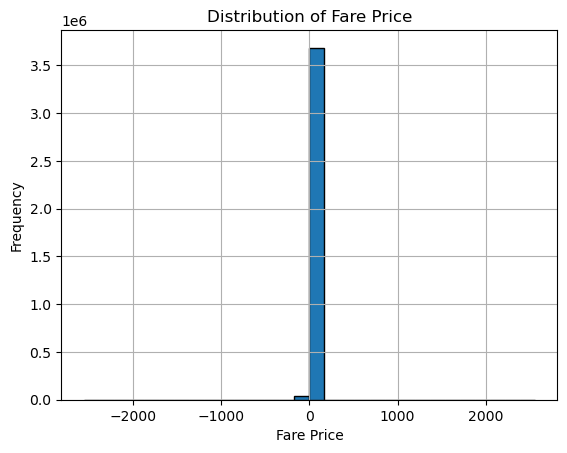

In [48]:
trips['fare_amount'].hist(bins=30, edgecolor='black')
plt.xlabel('Fare Price')
plt.ylabel('Frequency')
plt.title('Distribution of Fare Price')
plt.show()

In [49]:
print(trips['fare_amount'].describe())
print(trips['fare_amount'].quantile([0.01, 0.05, 0.5, 0.95, 0.99, 0.999]))

count    3.724889e+06
mean     2.080425e+01
std      1.892701e+01
min     -2.555200e+03
25%      1.000000e+01
50%      1.560000e+01
75%      2.610000e+01
max      2.555200e+03
Name: fare_amount, dtype: float64
0.010     -3.0
0.050      5.8
0.500     15.6
0.950     58.5
0.990     81.4
0.999    145.8
Name: fare_amount, dtype: float64


<h5>Based on the previous plot there's significant outliers in the data</h5>

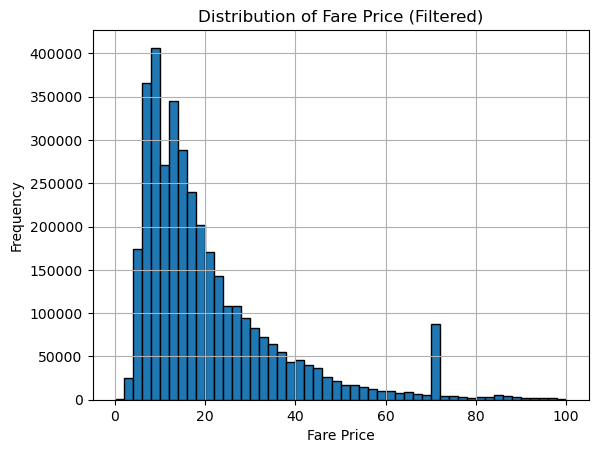

In [50]:
filtered = trips[(trips['fare_amount'] > 0) & (trips['fare_amount'] < 100)]
filtered['fare_amount'].hist(bins=50, edgecolor='black')
plt.xlabel('Fare Price')
plt.ylabel('Frequency')
plt.title('Distribution of Fare Price (Filtered)')
plt.show()

<h3>Dealing with Negative and zero Values</h3>

<h4>Let's Try to figure out the reason behind the zero and the negative values</h4>

In [51]:
anomalies = trips[trips['fare_amount'] <= 0].copy()
print(anomalies.shape)
anomalies = anomalies.dropna()
anomalies.describe()
print(anomalies.shape)

(41545, 19)
(40382, 19)


In [52]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score
# When creating features, dropna and keep track of the resulting index
features = anomalies[[
    'trip_distance', 'duration', 'RatecodeID',
    'is_airport_pickup', 'is_airport_dropoff', 'SameZone',
    'pick_up_hour', 'is_weekend'
]].copy()

borough_dummies = pd.get_dummies(
    anomalies[['boroughPickUpPoint', 'boroughDropOffPoint']],
    prefix=['pickup_boro', 'dropoff_boro']
)
features = pd.concat([features, borough_dummies], axis=1).dropna()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

<h4>Clustering the zero valued fares datapoints</h4>

In [53]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
for k in range(2,10):
    km = KMeans(n_clusters = k , random_state = 42 , n_init = 10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.471
k=3, silhouette=0.491
k=4, silhouette=0.500
k=5, silhouette=0.508
k=6, silhouette=0.506
k=7, silhouette=0.513
k=8, silhouette=0.519
k=9, silhouette=0.349


In [54]:
# Run KMeans
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Assign back using the SAME index as features (not the full anomalies df)
anomalies.loc[features.index, 'cluster'] = cluster_labels

In [55]:
anomalies.groupby('cluster')[['trip_distance', 'duration', 'RatecodeID']].mean()

,trip_distance,duration,RatecodeID
cluster,,,
0.0,1.501480,10.512454,1.084835
1.0,14.319102,39.155269,1.867297
2.0,5.812310,14.476358,1.316094
3.0,3.108714,11.842143,1.171429
4.0,19.406699,41.177508,3.533981
5.0,3.330535,13.266132,2.593583
6.0,30.975833,1502.358333,1.833333


In [56]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=10)
anomalies['cluster'] = dbscan.fit_predict(X_scaled)

anomalies.head()

anomalies.groupby('cluster')[['trip_distance' , 'duration']].agg(['mean' , 'count'])



trip_distance          duration       
                 mean  count       mean  count
cluster                                       
-1          10.403054   2374  37.382442   2374
 0           1.645488  15600  12.243723  15600
 1           0.206020   4070   2.629545   4070
 2           0.424369    753   1.658721    753
 3           5.848627     51  20.371569     51
...               ...    ...        ...    ...
 73          3.802308     13  25.765385     13
 74          1.327500     12   7.863889     12
 75         17.240000     10  28.548333     10
 76         13.124000     10  52.851667     10
 77         12.197000     10  24.083333     10

[79 rows x 4 columns]

<h4>After applying DBSCANE algorithm 2,320 row turned out to be noisy (doesn't belong to any group) meanwhile 15,600 rows are clustered under the umbrella of having the same pattern may be this was a coupon or a discount or a specific ratecodeID</h4>

In [57]:
anomalies.head()

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone,cluster
14,1,0.50,1.0,N,161,229,0.0,4.616667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0,0
74,2,0.63,1.0,N,143,143,-5.1,2.516667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1,1
248,2,1.92,1.0,N,170,79,-22.6,25.950000,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0,0
368,2,0.02,1.0,N,261,261,-3.0,0.633333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1,1
428,2,0.03,1.0,N,162,162,-3.0,0.633333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1,1


In [58]:
anomalies[anomalies['cluster'] == 0][['day_of_the_week','is_rush_hour','is_late_night','is_weekend','SameZone']].value_counts()

day_of_the_week  is_rush_hour  is_late_night  is_weekend  SameZone
4                0             0              0           0           2397
3                0             0              0           0           2245
2                0             0              0           0           1868
1                0             0              0           0           1648
0                0             0              0           0           1309
4                1             0              0           0           1245
3                1             0              0           0           1143
2                1             0              0           0            929
1                1             0              0           0            829
0                1             0              0           0            658
3                0             1              0           0            451
4                0             1              0           0            415
2                0             1 

In [59]:
#this is maybe a refund so we need to check for duplicate for all columns except the fare amount
cols_to_check = trips.columns.difference(['fare_amount'])
duplicates = trips[trips.duplicated(subset=cols_to_check, keep=False)]

In [60]:
duplicates

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone
74,2,0.63,1.0,N,143,143,-5.10,2.516667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
75,2,0.63,1.0,N,143,143,5.10,2.516667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
248,2,1.92,1.0,N,170,79,-22.60,25.950000,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0
249,2,1.92,1.0,N,170,79,22.60,25.950000,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0
368,2,0.02,1.0,N,261,261,-3.00,0.633333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3685448,1,3.80,NaN,None,140,68,20.40,22.533333,9,5,1,1,0,0,Manhattan,Manhattan,0,0,0
3703485,2,2.96,NaN,None,239,74,19.98,15.066667,18,5,1,1,0,0,Manhattan,Manhattan,0,0,0
3703877,2,2.96,NaN,None,239,74,19.95,15.066667,18,5,1,1,0,0,Manhattan,Manhattan,0,0,0
3708351,2,1.53,NaN,None,236,237,41.02,11.283333,19,5,1,1,0,0,Manhattan,Manhattan,0,0,0


In [61]:
cols_to_check = trips.columns.difference(['fare_amount'])

duplicates = trips[trips.duplicated(subset=cols_to_check, keep=False)]

negative_fares = trips[trips['fare_amount'] < 0]

matches = trips.merge(
    negative_fares[cols_to_check],
    on=list(cols_to_check),
    how='inner'
)

In [62]:
matches.head(20)

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone
0,2,0.63,1.0,N,143,143,-5.1,2.516667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
1,2,0.63,1.0,N,143,143,5.1,2.516667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
2,2,1.92,1.0,N,170,79,-22.6,25.950000,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0
3,2,1.92,1.0,N,170,79,22.6,25.950000,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0
4,2,0.02,1.0,N,261,261,-3.0,0.633333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
5,2,0.02,1.0,N,261,261,3.0,0.633333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
6,2,0.03,1.0,N,162,162,-3.0,0.633333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
7,2,0.03,1.0,N,162,162,3.0,0.633333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
8,2,3.12,1.0,N,161,263,-22.6,25.033333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0
9,2,3.12,1.0,N,161,263,22.6,25.033333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,0


<h4>It has proven my point of view that these rows with negative values are representing refunds for actual rows not a data entry error</h4>

In [63]:
trips = trips[trips['fare_amount'] > 0]
trips[trips['fare_amount'] <= 0].count()

VendorID               0
trip_distance          0
RatecodeID             0
store_and_fwd_flag     0
PULocationID           0
DOLocationID           0
fare_amount            0
duration               0
pick_up_hour           0
day_of_the_week        0
pick_up_month          0
is_weekend             0
is_rush_hour           0
is_late_night          0
boroughPickUpPoint     0
boroughDropOffPoint    0
is_airport_pickup      0
is_airport_dropoff     0
SameZone               0
dtype: int64

In [64]:
trips['fare_amount'].value_counts()

fare_amount
7.90      124439
8.60      123644
9.30      121894
7.20      118839
10.00     118754
           ...  
164.45         1
133.73         1
116.31         1
155.17         1
99.94          1
Name: count, Length: 12170, dtype: int64

<h4>Checking the distribution of the fare_amount after removing the negative values</h4>

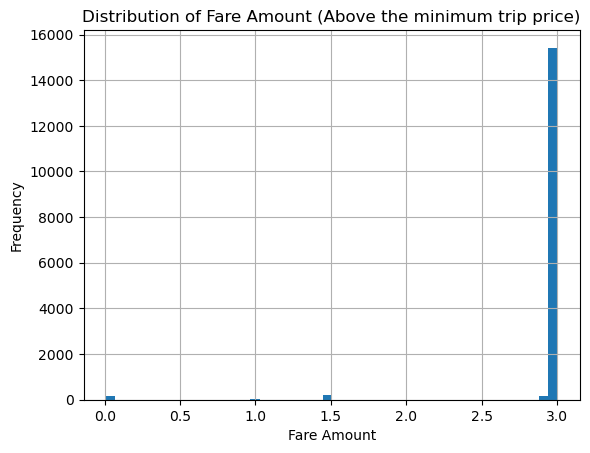

In [65]:
trips[trips['fare_amount']<=3]['fare_amount'].hist(bins=50) #3 becuase this is the lowest trip price based on the documentation of the dataset
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Fare Amount (Above the minimum trip price)')
plt.show()

In [66]:
trips = trips[trips['fare_amount'] >= 3]
trips[trips['fare_amount'] < 3].count()

VendorID               0
trip_distance          0
RatecodeID             0
store_and_fwd_flag     0
PULocationID           0
DOLocationID           0
fare_amount            0
duration               0
pick_up_hour           0
day_of_the_week        0
pick_up_month          0
is_weekend             0
is_rush_hour           0
is_late_night          0
boroughPickUpPoint     0
boroughDropOffPoint    0
is_airport_pickup      0
is_airport_dropoff     0
SameZone               0
dtype: int64

In [67]:
FareAmountMedian = trips['fare_amount'].median()
print(FareAmountMedian)

15.6


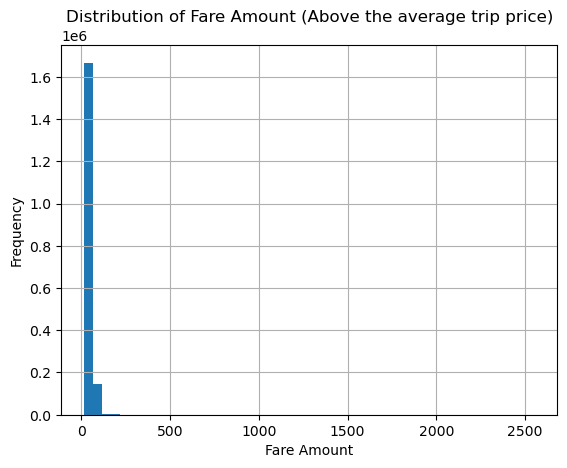

In [68]:
trips[trips['fare_amount']>15.6]['fare_amount'].hist(bins=50) #3 becuase this is the lowest trip price based on the documentation of the dataset
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Fare Amount (Above the average trip price)')
plt.show()

In [69]:
Q1 = trips['fare_amount'].quantile(0.25)
Q3 = trips['fare_amount'].quantile(0.75)
IQR = Q3 - Q1
print('Q1=' + str(Q1))
print('Q3=' + str(Q3))

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = trips[(trips['fare_amount'] < lower_bound) | (trips['fare_amount'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(f"Bounds: {lower_bound} to {upper_bound}")

Q1=10.0
Q3=26.18
Number of outliers: 246549
Bounds: -14.27 to 50.45


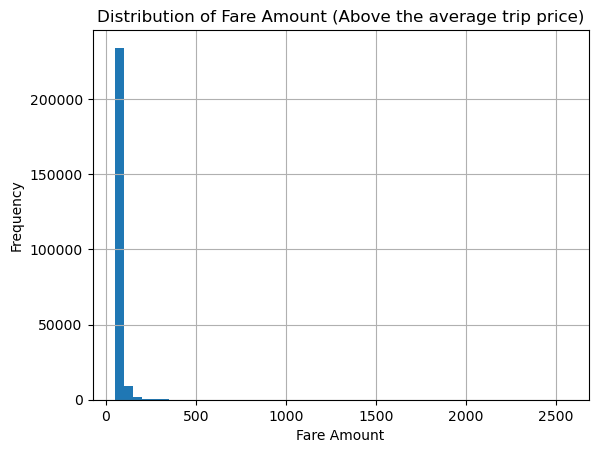

In [70]:
trips[trips['fare_amount']>50.45]['fare_amount'].hist(bins=50) #3 becuase this is the lowest trip price based on the documentation of the dataset
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Fare Amount (Above the average trip price)')
plt.show()

In [71]:
trips[trips['fare_amount']>100].head(20)


,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone
404,2,11.49,5.0,N,48,265,135.00,18.700000,0,3,1,0,0,1,Manhattan,None,0,0,0
982,2,40.14,3.0,N,132,1,167.20,65.683333,23,2,12,0,0,1,Queens,EWR,1,1,0
1270,2,0.00,5.0,N,265,265,124.00,0.100000,0,3,1,0,0,1,None,None,0,0,1
1641,2,0.00,5.0,N,107,107,200.00,0.183333,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
2359,2,0.00,5.0,N,50,50,200.00,0.166667,0,3,1,0,0,1,Manhattan,Manhattan,0,0,1
3087,2,49.83,5.0,N,186,265,475.00,77.950000,0,3,1,0,0,1,Manhattan,None,0,0,0
3134,1,0.00,5.0,N,265,265,120.00,0.083333,0,3,1,0,0,1,None,None,0,0,1
3267,7,23.09,5.0,N,164,265,135.00,0.000000,0,3,1,0,0,1,Manhattan,None,0,0,0
3283,2,6.90,5.0,N,161,265,132.00,41.683333,0,3,1,0,0,1,Manhattan,None,0,0,0
3286,2,20.89,4.0,N,138,265,101.00,27.283333,0,3,1,0,0,1,Queens,None,1,0,0


In [72]:
outliers = trips[(trips['fare_amount'] < lower_bound) | (trips['fare_amount'] > upper_bound)]

# Compare average distance for outliers vs normal fares
print("Outliers avg distance:", outliers['trip_distance'].mean())
print("Normal avg distance:", trips[~trips.index.isin(outliers.index)]['trip_distance'].mean())

Outliers avg distance: 18.151434116544785
Normal avg distance: 5.645475033795139


<h5>the average distance increases with the average fare price so the prices over 50$(upper bound) is not completely outliers</h5>

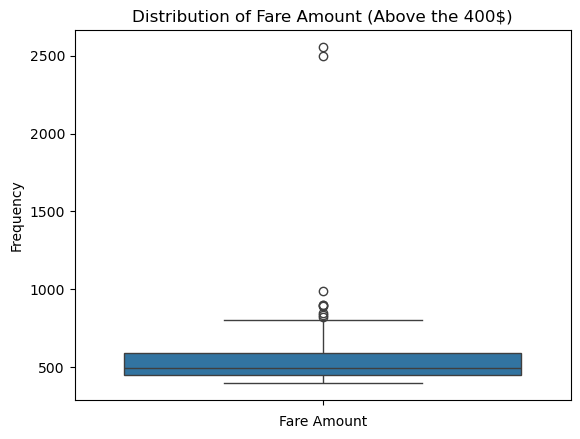

In [73]:
sns.boxplot(trips[trips['fare_amount']>400]['fare_amount']) #3 becuase this is the lowest trip price based on the documentation of the dataset
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Fare Amount (Above the 400$)')
plt.show()

In [74]:
trips[trips['fare_amount']>700]

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone
28464,2,0.00,5.0,N,41,41,800.0,0.516667,12,3,1,0,0,0,Manhattan,Manhattan,0,0,1
84952,1,0.00,99.0,N,264,264,850.0,0.000000,12,4,1,0,0,0,Unknown,Unknown,0,0,1
266099,2,123.18,4.0,N,132,265,797.5,134.133333,16,6,1,1,0,0,Queens,None,1,0,0
290678,2,121.69,4.0,N,138,265,762.5,118.333333,0,0,1,0,0,1,Queens,None,1,0,0
670319,2,0.03,5.0,N,76,63,800.0,0.133333,13,4,1,0,0,0,Brooklyn,Brooklyn,0,0,0
957057,2,66.05,1.0,N,193,193,801.7,0.133333,15,0,1,0,0,0,Queens,Queens,0,0,1
1230759,1,0.00,99.0,N,264,264,2500.0,0.000000,13,3,1,0,0,0,Unknown,Unknown,0,0,1
1586362,2,116.46,4.0,N,265,265,826.2,117.083333,13,0,1,0,0,0,None,None,0,0,1
1608067,2,0.00,5.0,N,24,24,990.0,0.083333,17,0,1,0,1,0,Manhattan,Manhattan,0,0,1
1847335,2,121.18,4.0,N,250,265,837.4,133.883333,10,3,1,0,0,0,Bronx,None,0,0,0


In [75]:
#since RateCodeId #99 represents unkown
trips = trips[~(trips['RatecodeID'] == 99)]
trips[trips['fare_amount']>700]

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone
28464,2,0.00,5.0,N,41,41,800.0,0.516667,12,3,1,0,0,0,Manhattan,Manhattan,0,0,1
266099,2,123.18,4.0,N,132,265,797.5,134.133333,16,6,1,1,0,0,Queens,None,1,0,0
290678,2,121.69,4.0,N,138,265,762.5,118.333333,0,0,1,0,0,1,Queens,None,1,0,0
670319,2,0.03,5.0,N,76,63,800.0,0.133333,13,4,1,0,0,0,Brooklyn,Brooklyn,0,0,0
957057,2,66.05,1.0,N,193,193,801.7,0.133333,15,0,1,0,0,0,Queens,Queens,0,0,1
1586362,2,116.46,4.0,N,265,265,826.2,117.083333,13,0,1,0,0,0,None,None,0,0,1
1608067,2,0.00,5.0,N,24,24,990.0,0.083333,17,0,1,0,1,0,Manhattan,Manhattan,0,0,1
1847335,2,121.18,4.0,N,250,265,837.4,133.883333,10,3,1,0,0,0,Bronx,None,0,0,0
1877445,2,120.31,4.0,N,132,265,786.3,186.216667,15,3,1,0,0,0,Queens,None,1,0,0
2035988,2,9.03,5.0,N,147,146,900.0,24.883333,0,5,1,1,0,1,Bronx,Queens,0,0,0


In [76]:
trips = trips[~((trips['fare_amount'] > 900)&(trips['RatecodeID'] == 1.0))]
trips[trips['fare_amount']>700]

,VendorID,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,fare_amount,duration,pick_up_hour,day_of_the_week,pick_up_month,is_weekend,is_rush_hour,is_late_night,boroughPickUpPoint,boroughDropOffPoint,is_airport_pickup,is_airport_dropoff,SameZone
28464,2,0.00,5.0,N,41,41,800.0,0.516667,12,3,1,0,0,0,Manhattan,Manhattan,0,0,1
266099,2,123.18,4.0,N,132,265,797.5,134.133333,16,6,1,1,0,0,Queens,None,1,0,0
290678,2,121.69,4.0,N,138,265,762.5,118.333333,0,0,1,0,0,1,Queens,None,1,0,0
670319,2,0.03,5.0,N,76,63,800.0,0.133333,13,4,1,0,0,0,Brooklyn,Brooklyn,0,0,0
957057,2,66.05,1.0,N,193,193,801.7,0.133333,15,0,1,0,0,0,Queens,Queens,0,0,1
1586362,2,116.46,4.0,N,265,265,826.2,117.083333,13,0,1,0,0,0,None,None,0,0,1
1608067,2,0.00,5.0,N,24,24,990.0,0.083333,17,0,1,0,1,0,Manhattan,Manhattan,0,0,1
1847335,2,121.18,4.0,N,250,265,837.4,133.883333,10,3,1,0,0,0,Bronx,None,0,0,0
1877445,2,120.31,4.0,N,132,265,786.3,186.216667,15,3,1,0,0,0,Queens,None,1,0,0
2035988,2,9.03,5.0,N,147,146,900.0,24.883333,0,5,1,1,0,1,Bronx,Queens,0,0,0


<h3>In this Notebook We have successfully handled the fare_amount column from outliers and null values now let's move on to the next step with (trips_distance , duration) columns in the DataCleaning & Preprocessing notebook Part 2<h3>

In [77]:
trips.to_parquet('Trips_phase2.parquet')